## Historical v1 experiment

This notebook records the earlier 4,000-row methodology. For the current 10,000-row experiment, run `../ml/train_model.py` and consult `../ml/README.md` and `../ml/reports/evaluation_report.json`. Its stored results are not v2 results.


# 02 — SVM Model Training and Evaluation

**Intelligent Agent Identity Verification System — Module 12**

This notebook trains the multi-class Support Vector Machine that replaces the Module 8 placeholder threshold rules in the
access-control module. It is written as academic documentation of the full experimental process:

1. Data loading and exploration
2. Preprocessing (label encoding, stratified 70/15/15 split, Min-Max normalisation)
3. SVM training with `GridSearchCV` over `C` and `gamma`
4. Decision Tree comparison model
5. Validation-set evaluation
6. Held-out test-set evaluation (classification reports, confusion matrices, F1 comparison)
7. Feature importance (permutation importance for the SVM, impurity importance for the tree)
8. Saving the model and scaler for the Python AI service

The dataset is produced by `ml/generate_dataset.py` using the distributions documented in
`01_distribution_analysis.ipynb`. The production retraining script `ml/train_model.py` reproduces steps 2, 3 (with the
tuned hyperparameters hard-coded), 6 and 8 non-interactively.

In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_recall_fscore_support)
from sklearn.inspection import permutation_importance

%matplotlib inline

# scikit-learn >= 1.9 emits a FutureWarning for SVC(probability=True). Platt-scaled
# probabilities are still required by the API contract, so the warning is silenced here.
warnings.filterwarnings('ignore', message='.*probability.*', category=FutureWarning)

RANDOM_STATE = 42
DATA_PATH = os.path.join('..', 'ml', 'data', 'synthetic_verification_dataset.csv')
MODEL_DIR = os.path.join('..', 'ml', 'legacy_v1', 'notebook_models')

FEATURES = ['faceMatchScore', 'livenessScore', 'ocrConfidenceScore',
            'blurScore', 'brightnessScore', 'contrastScore']
CLASS_NAMES = ['Verified', 'Manual Review', 'Rejected']   # label 0, 1, 2
CLASS_COLOURS = ['#2a78d6', '#eb6834', '#1baf7a']
MODEL_COLOURS = {'SVM': '#2a78d6', 'Decision Tree': '#eb6834'}

plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'figure.dpi': 100})

## Section 1 — Data loading and exploration

The dataset contains 4,000 synthetic applicants, each described by the six verification scores and a label encoded as
`0 = Verified`, `1 = Manual Review`, `2 = Rejected`.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (4000, 7)


,faceMatchScore,livenessScore,ocrConfidenceScore,blurScore,brightnessScore,contrastScore,label
0,88.4353,0.9273,0.8534,150.4332,125.6597,70.1967,0
1,35.3976,0.2604,0.2566,36.0439,1.3173,0.0446,2
2,87.6699,0.8586,0.7267,166.6840,160.4270,63.8563,0
3,25.3807,0.3964,0.3134,28.6513,21.1263,20.2270,2
4,80.5348,0.6245,0.4832,53.2697,78.2233,21.1917,1


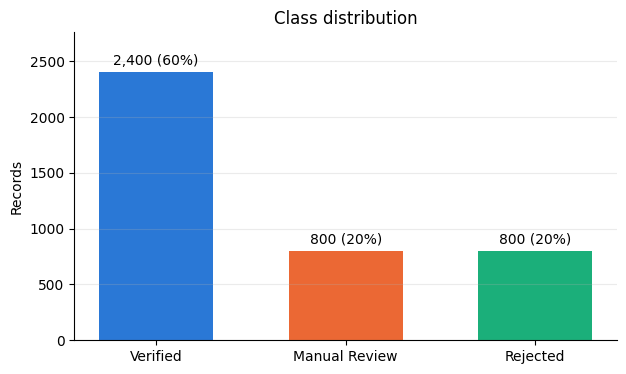

In [3]:
# Class distribution — the dataset is intentionally imbalanced (60 / 20 / 20) to mirror a
# production funnel where most applicants are genuine.
counts = df['label'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(CLASS_NAMES, counts.values, color=CLASS_COLOURS, width=0.6)
ax.bar_label(bars, labels=[f'{c:,} ({c / len(df):.0%})' for c in counts.values], padding=3)
ax.set_ylabel('Records')
ax.set_title('Class distribution')
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis='x', visible=False)
plt.show()

In [4]:
# Descriptive statistics for each feature (all classes pooled)
df[FEATURES].describe().round(3)

,faceMatchScore,livenessScore,ocrConfidenceScore,blurScore,brightnessScore,contrastScore
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,72.378,0.712,0.651,109.027,105.064,45.315
std,21.539,0.238,0.239,57.465,60.747,26.264
min,0.858,0.000,0.000,0.244,0.000,0.000
25%,58.843,0.565,0.489,55.117,47.326,18.346
50%,82.040,0.826,0.759,121.204,121.173,53.233
75%,88.244,0.890,0.832,156.673,149.932,67.580
max,100.000,1.000,1.000,280.684,253.274,101.316


In [5]:
# Per-class means show how strongly each feature shifts between classes
per_class = df.groupby('label')[FEATURES].mean().round(3)
per_class.index = CLASS_NAMES
per_class

,faceMatchScore,livenessScore,ocrConfidenceScore,blurScore,brightnessScore,contrastScore
Verified,87.253,0.878,0.820,150.568,139.936,65.052
Manual Review,64.774,0.622,0.547,63.673,88.747,21.764
Rejected,35.356,0.302,0.249,29.759,16.763,9.655


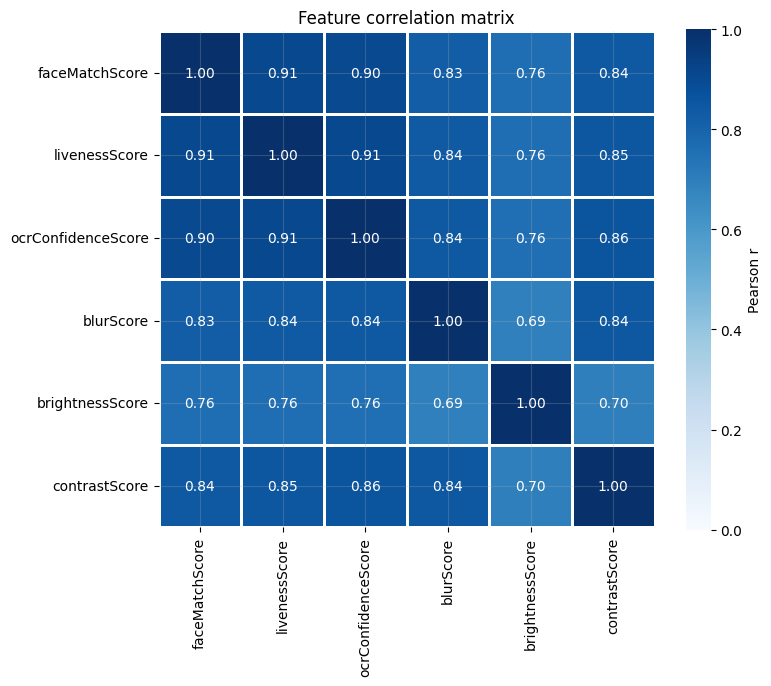

In [6]:
# Correlation heatmap of the six features. Strong positive correlations are expected because every
# feature is shifted in the same direction by the class label (class-induced correlation), even though
# features are sampled independently *within* each class.
corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True,
            linewidths=2, linecolor='white', cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature correlation matrix')
plt.show()

**Observation.** All features are strongly positively correlated with each other. This is class-induced: within a class
the features are independent, but because Verified applicants score high on *every* signal and Rejected applicants
low on every signal, the pooled data shows high correlation. This redundancy is important when interpreting feature
importance in Section 7.

## Section 2 — Preprocessing

### 2.1 Label encoding
Labels are already integers. `LabelEncoder` is applied as a guard to guarantee contiguous class indices `0 … K-1`,
which the API relies on to map predictions back to `verified / review / rejected`.

In [7]:
X = df[FEATURES].values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'].values)
print('Encoder classes:', label_encoder.classes_, '→', dict(zip(label_encoder.classes_, CLASS_NAMES)))

Encoder classes: [0 1 2] → {np.int64(0): 'Verified', np.int64(1): 'Manual Review', np.int64(2): 'Rejected'}


### 2.2 Stratified train / validation / test split (70 / 15 / 15)

Two successive `train_test_split` calls with `stratify` and `random_state=42`:
first 70 % train vs. 30 % hold-out, then the hold-out split 50 / 50 into validation and test.

*Methodological note:* the split is performed **before** normalisation so that the `MinMaxScaler` is fitted on the
training data only. Fitting the scaler on the full dataset would leak the minimum and maximum of the validation and
test sets into training.

In [8]:
X_train_raw, X_hold_raw, y_train, y_hold = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_hold_raw, y_hold, test_size=0.50, stratify=y_hold, random_state=RANDOM_STATE)

split_summary = pd.DataFrame({
    name: pd.Series(labels).value_counts(normalize=True).sort_index().values
    for name, labels in [('Full', y), ('Train', y_train), ('Validation', y_val), ('Test', y_test)]
}, index=CLASS_NAMES)
split_summary.loc['Records'] = [len(y), len(y_train), len(y_val), len(y_test)]
split_summary.round(3)

,Full,Train,Validation,Test
Verified,0.6,0.6,0.6,0.6
Manual Review,0.2,0.2,0.2,0.2
Rejected,0.2,0.2,0.2,0.2
Records,4000.0,2800.0,600.0,600.0


The class proportions (60 / 20 / 20) are preserved in every split.

### 2.3 Min-Max normalisation

The features live on very different scales (liveness in [0, 1], brightness in [0, 255]). The RBF kernel is based on
Euclidean distance, so unscaled features with large ranges would dominate. `MinMaxScaler` maps each feature to [0, 1]
using the training-set minimum and maximum.

`clip=True` is set so that production inputs outside the training range (for example a very sharp capture with a
Laplacian variance above 300) are clamped to the nearest edge of the learned feature space instead of being
extrapolated into regions the RBF kernel has never seen.

In [9]:
scaler = MinMaxScaler(clip=True)
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

pd.DataFrame({'train min': scaler.data_min_, 'train max': scaler.data_max_}, index=FEATURES).round(3)

,train min,train max
faceMatchScore,6.623,100.000
livenessScore,0.000,1.000
ocrConfidenceScore,0.000,1.000
blurScore,0.244,247.818
brightnessScore,0.000,253.274
contrastScore,0.000,99.935


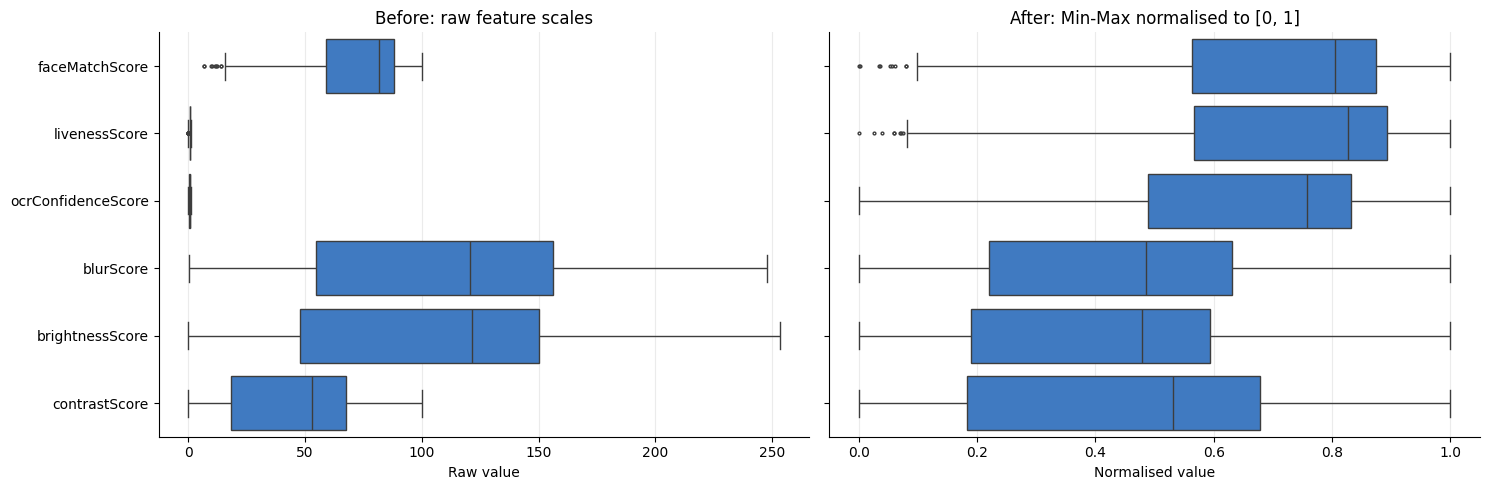

In [10]:
# Before vs. after normalisation (training set)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
before = pd.DataFrame(X_train_raw, columns=FEATURES)
after = pd.DataFrame(X_train, columns=FEATURES)

sns.boxplot(data=before, orient='h', ax=axes[0], color='#2a78d6', fliersize=2)
axes[0].set_title('Before: raw feature scales')
axes[0].set_xlabel('Raw value')

sns.boxplot(data=after, orient='h', ax=axes[1], color='#2a78d6', fliersize=2)
axes[1].set_title('After: Min-Max normalised to [0, 1]')
axes[1].set_xlabel('Normalised value')
axes[1].set_yticklabels([])
fig.tight_layout()
plt.show()

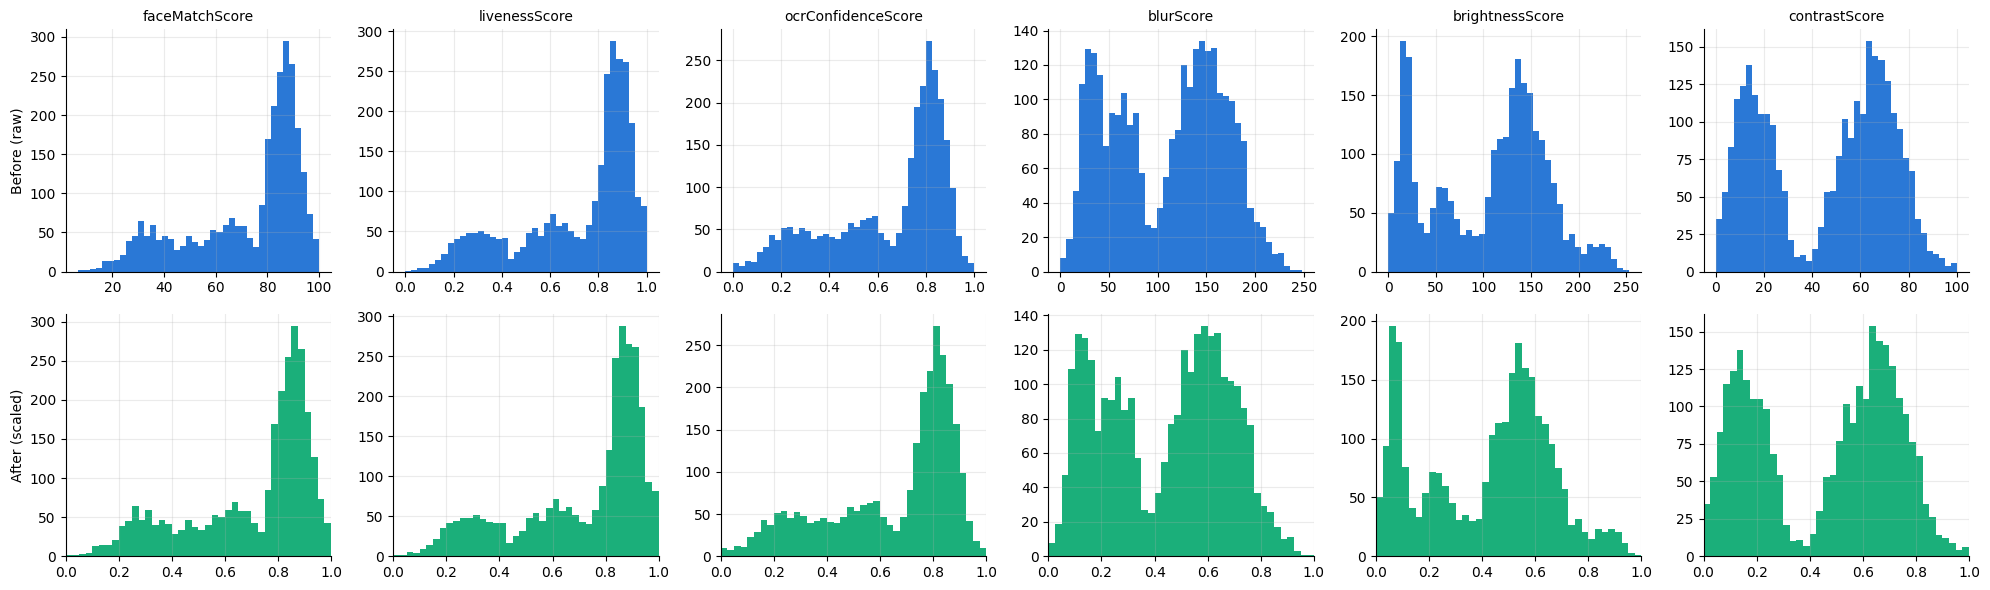

In [11]:
# Per-feature histograms before and after — the shape is unchanged, only the axis is rescaled
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
for i, feat in enumerate(FEATURES):
    axes[0, i].hist(before[feat], bins=40, color='#2a78d6')
    axes[0, i].set_title(feat, fontsize=10)
    axes[1, i].hist(after[feat], bins=40, color='#1baf7a')
    axes[1, i].set_xlim(0, 1)
axes[0, 0].set_ylabel('Before (raw)')
axes[1, 0].set_ylabel('After (scaled)')
fig.tight_layout()
plt.show()

## Section 3 — SVM model training

### 3.1 Base configuration
* `kernel='rbf'` — the radial basis function kernel lets the SVM learn non-linear decision boundaries.
* `class_weight='balanced'` — weights each class inversely to its frequency so the 20 % minority classes
  (Manual Review and Rejected) contribute as much to the loss as the 60 % Verified class.
* `random_state=42` — reproducibility.

scikit-learn's `SVC` handles the three classes with a one-vs-one scheme (three binary SVMs, majority vote).

### 3.2 Hyperparameter search
* `C` controls the trade-off between a wide margin and training errors (small `C` = smoother boundary).
* `gamma` controls the reach of each support vector in the RBF kernel (small `gamma` = smoother boundary).

`GridSearchCV` evaluates all 4 × 6 = 24 combinations with stratified 5-fold cross-validation on the training set,
using macro-averaged F1 so that each class counts equally regardless of its size.

In [12]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto'],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

BEST_C = grid_search.best_params_['C']
BEST_GAMMA = grid_search.best_params_['gamma']
print('=' * 50)
print(f'  Best C          : {BEST_C}')
print(f'  Best gamma      : {BEST_GAMMA}')
print(f'  Best CV macro F1: {grid_search.best_score_:.4f}')
print('=' * 50)

  Best C          : 0.1
  Best gamma      : 0.1
  Best CV macro F1: 1.0000


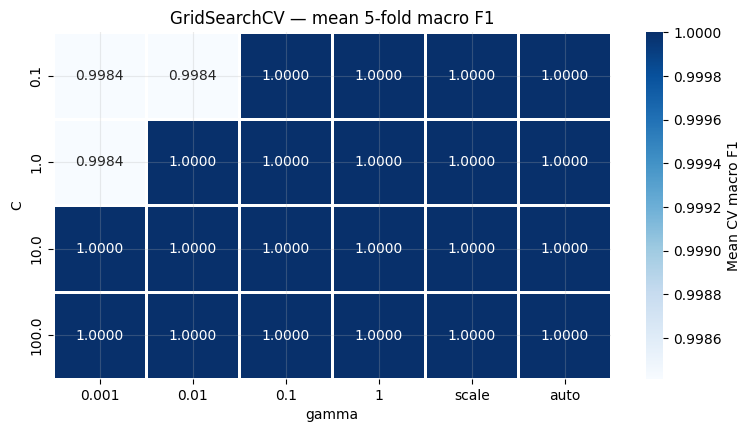

21 of 24 combinations reach a CV macro F1 of 1.0000


In [13]:
# Mean cross-validated macro F1 for every (C, gamma) combination
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results['gamma'] = cv_results['param_gamma'].astype(str)
cv_results['C'] = cv_results['param_C'].astype(float)
pivot = cv_results.pivot(index='C', columns='gamma', values='mean_test_score')
pivot = pivot[[str(g) for g in param_grid['gamma']]]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', linewidths=2, linecolor='white',
            cbar_kws={'label': 'Mean CV macro F1'}, ax=ax)
ax.set_title('GridSearchCV — mean 5-fold macro F1')
plt.show()

n_perfect = int((cv_results['mean_test_score'] >= 0.9999).sum())
print(f'{n_perfect} of {len(cv_results)} combinations reach a CV macro F1 of 1.0000')

**Tie-breaking.** Several combinations achieve the maximum score. `GridSearchCV` returns the first top-ranked
combination in grid order, which is the one with the **smallest `C`** among the ties. A small `C` gives the widest
margin and the smoothest decision boundary, which is the preferable choice when multiple settings fit the training data
equally well, because it is least likely to overfit to the synthetic class boundaries.

### 3.3 Retrain on the full training set
The final SVM is refitted with the selected hyperparameters and `probability=True`, which adds Platt scaling (an
internal 5-fold logistic calibration) so the model can return `verifiedProbability`, `reviewProbability` and
`rejectedProbability` to the backend.

In [14]:
svm_model = SVC(
    kernel='rbf',
    C=BEST_C,
    gamma=BEST_GAMMA,
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
)
svm_model.fit(X_train, y_train)
print(svm_model)
print('Support vectors per class:', dict(zip(CLASS_NAMES, svm_model.n_support_)))

SVC(C=0.1, class_weight='balanced', gamma=0.1, probability=True,
    random_state=42)
Support vectors per class: {'Verified': np.int32(534), 'Manual Review': np.int32(409), 'Rejected': np.int32(235)}


## Section 4 — Decision Tree comparison model

A depth-limited Decision Tree serves as an interpretable baseline. `max_depth=5` keeps the tree small enough to be
readable, `class_weight='balanced'` matches the SVM's treatment of imbalance. No hyperparameter tuning is performed for
the comparison model. The tree is trained on the same scaled features (trees are scale-invariant, so this does not
affect its splits, only their numeric thresholds).

In [15]:
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
print(dt_model)
print(f'Depth: {dt_model.get_depth()}, leaves: {dt_model.get_n_leaves()}')

DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)
Depth: 5, leaves: 8


## Section 5 — Validation set evaluation

The validation set (15 %) is used to confirm the chosen SVM configuration before touching the test set.

In [16]:
models = {'SVM': svm_model, 'Decision Tree': dt_model}

for name, model in models.items():
    y_val_pred = model.predict(X_val)
    print(f'--- {name} (validation) ---')
    print(classification_report(y_val, y_val_pred, target_names=CLASS_NAMES, digits=4))
    print(f'Accuracy: {accuracy_score(y_val, y_val_pred):.4f}\n')

--- SVM (validation) ---


               precision    recall  f1-score   support

     Verified     1.0000    1.0000    1.0000       360
Manual Review     1.0000    1.0000    1.0000       120
     Rejected     1.0000    1.0000    1.0000       120

     accuracy                         1.0000       600
    macro avg     1.0000    1.0000    1.0000       600
 weighted avg     1.0000    1.0000    1.0000       600

Accuracy: 1.0000

--- Decision Tree (validation) ---
               precision    recall  f1-score   support

     Verified     1.0000    1.0000    1.0000       360
Manual Review     0.9917    1.0000    0.9959       120
     Rejected     1.0000    0.9917    0.9958       120

     accuracy                         0.9983       600
    macro avg     0.9972    0.9972    0.9972       600
 weighted avg     0.9983    0.9983    0.9983       600

Accuracy: 0.9983



In [17]:
svm_val_f1 = f1_score(y_val, svm_model.predict(X_val), average='macro')
dt_val_f1 = f1_score(y_val, dt_model.predict(X_val), average='macro')
print(f'Validation macro F1 — SVM: {svm_val_f1:.4f} | Decision Tree: {dt_val_f1:.4f}')
print(f'Cross-validation macro F1 of chosen SVM config: {grid_search.best_score_:.4f}')
if svm_val_f1 >= dt_val_f1:
    print('SVM configuration confirmed: it matches or outperforms the baseline on unseen validation data.')
else:
    print('WARNING: Decision Tree outperforms the SVM on validation — revisit the configuration.')

Validation macro F1 — SVM: 1.0000 | Decision Tree: 0.9972
Cross-validation macro F1 of chosen SVM config: 1.0000
SVM configuration confirmed: it matches or outperforms the baseline on unseen validation data.


## Section 6 — Test set evaluation

The held-out test set (15 %, 600 records) was not used for training, tuning or configuration selection. These are the
figures reported for the model.

In [18]:
test_predictions = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    test_predictions[name] = y_pred
    print(f'=== {name} (test) ===')
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))
    print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'Macro F1 : {f1_score(y_test, y_pred, average="macro"):.4f}\n')

=== SVM (test) ===
               precision    recall  f1-score   support

     Verified     1.0000    1.0000    1.0000       360
Manual Review     1.0000    1.0000    1.0000       120
     Rejected     1.0000    1.0000    1.0000       120

     accuracy                         1.0000       600
    macro avg     1.0000    1.0000    1.0000       600
 weighted avg     1.0000    1.0000    1.0000       600

Accuracy : 1.0000
Macro F1 : 1.0000

=== Decision Tree (test) ===
               precision    recall  f1-score   support

     Verified     1.0000    1.0000    1.0000       360
Manual Review     1.0000    0.9917    0.9958       120
     Rejected     0.9917    1.0000    0.9959       120

     accuracy                         0.9983       600
    macro avg     0.9972    0.9972    0.9972       600
 weighted avg     0.9983    0.9983    0.9983       600

Accuracy : 0.9983
Macro F1 : 0.9972



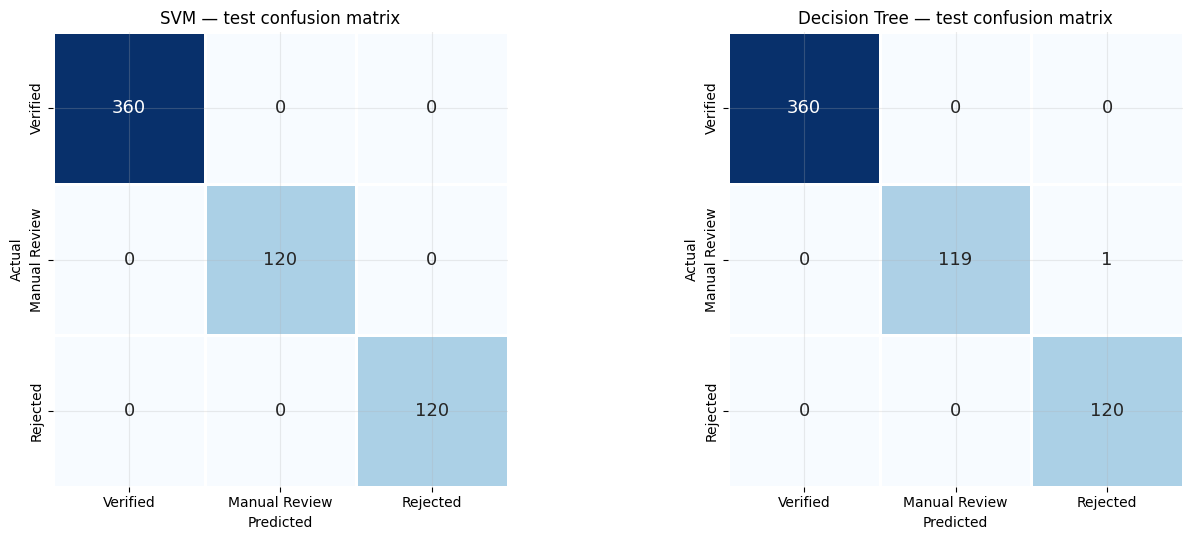

In [19]:
# Confusion matrices. Off-diagonal cells are misclassifications; the most costly error for KYC
# is a Rejected applicant predicted as Verified (bottom-left cell).
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (name, y_pred) in zip(axes, test_predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, square=True,
                linewidths=2, linecolor='white',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax, annot_kws={'size': 13})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — test confusion matrix')
fig.tight_layout()
plt.show()

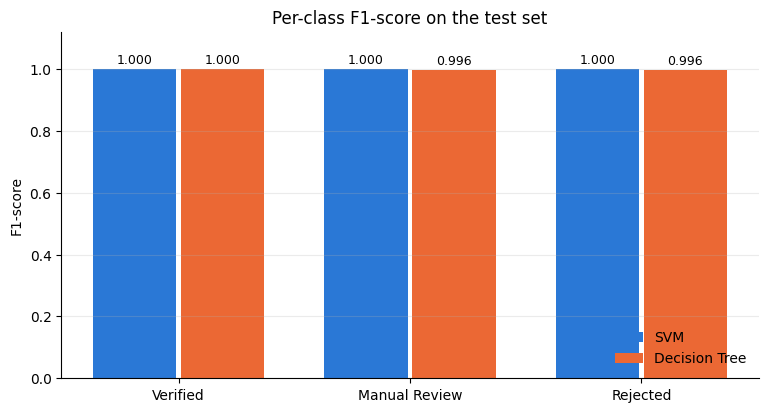

Model,Decision Tree,SVM
Class,,
Verified,1.0000,1.0
Manual Review,0.9958,1.0
Rejected,0.9959,1.0


In [20]:
# Side-by-side per-class F1 comparison
f1_rows = []
for name, y_pred in test_predictions.items():
    _, _, f1s, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2], zero_division=0)
    for cls, value in zip(CLASS_NAMES, f1s):
        f1_rows.append({'Model': name, 'Class': cls, 'F1': value})
f1_df = pd.DataFrame(f1_rows)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(CLASS_NAMES))
width = 0.36
for i, name in enumerate(models):
    vals = f1_df[f1_df['Model'] == name]['F1'].values
    bars = ax.bar(x + (i - 0.5) * (width + 0.02), vals, width, label=name, color=MODEL_COLOURS[name])
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in vals], padding=2, fontsize=9)
ax.set_xticks(x, CLASS_NAMES)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.12)  # bars start at zero; the value labels show the small differences
ax.set_title('Per-class F1-score on the test set')
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='x', visible=False)
plt.show()

f1_df.pivot(index='Class', columns='Model', values='F1').loc[CLASS_NAMES].round(4)

**Interpretation.** Both models score close to perfectly, which is expected: the agreed class distributions occupy
non-overlapping ranges on every feature, so the classes are separable almost everywhere except in the thin band
created by the injected noise. The comparison is therefore decided by how each model handles that boundary band.
The SVM's smooth maximum-margin boundary uses all six features together, whereas the depth-5 tree cuts on one
feature at a time with axis-aligned thresholds, so the tree's errors (if any) appear on the Manual Review / Rejected
boundary, where a record whose chosen split feature happens to fall on the wrong side of a threshold is misrouted.

These figures should not be read as an estimate of real-world accuracy; see *Limitations* at the end.

## Section 7 — Feature importance analysis

* **SVM — permutation importance.** An RBF SVM has no native feature weights. Permutation importance measures the drop
  in macro F1 on the test set when one feature's values are randomly shuffled (breaking its relationship with the
  label), repeated 30 times.
* **Decision Tree — impurity importance.** `feature_importances_` is the total reduction in Gini impurity contributed
  by splits on each feature.

In [21]:
perm = permutation_importance(svm_model, X_test, y_test, n_repeats=30,
                              random_state=RANDOM_STATE, scoring='f1_macro', n_jobs=-1)
importance = pd.DataFrame({
    'SVM permutation (mean ΔF1)': perm.importances_mean,
    'SVM permutation (std)': perm.importances_std,
    'Decision Tree (Gini)': dt_model.feature_importances_,
}, index=FEATURES).sort_values('SVM permutation (mean ΔF1)', ascending=False)
importance.round(4)

,SVM permutation (mean ΔF1),SVM permutation (std),Decision Tree (Gini)
livenessScore,0.1036,0.0105,0.4626
ocrConfidenceScore,0.0904,0.0109,0.0290
faceMatchScore,0.0853,0.0090,0.0000
contrastScore,0.0498,0.0051,0.5013
blurScore,0.0130,0.0038,0.0071
brightnessScore,0.0074,0.0056,0.0000


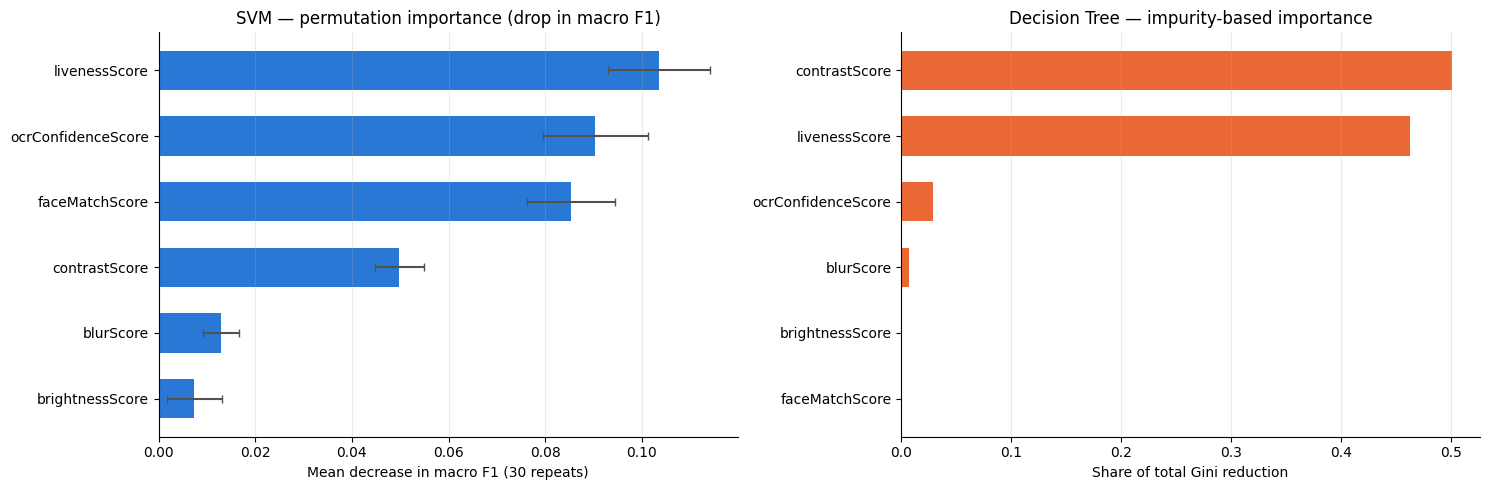

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

svm_sorted = importance.sort_values('SVM permutation (mean ΔF1)')
axes[0].barh(svm_sorted.index, svm_sorted['SVM permutation (mean ΔF1)'],
             xerr=svm_sorted['SVM permutation (std)'], color=MODEL_COLOURS['SVM'], height=0.6,
             error_kw={'ecolor': '#52514e', 'capsize': 3})
axes[0].set_title('SVM — permutation importance (drop in macro F1)')
axes[0].set_xlabel('Mean decrease in macro F1 (30 repeats)')

dt_sorted = importance.sort_values('Decision Tree (Gini)')
axes[1].barh(dt_sorted.index, dt_sorted['Decision Tree (Gini)'], color=MODEL_COLOURS['Decision Tree'], height=0.6)
axes[1].set_title('Decision Tree — impurity-based importance')
axes[1].set_xlabel('Share of total Gini reduction')

for ax in axes:
    ax.grid(axis='y', visible=False)
fig.tight_layout()
plt.show()

### 7.1 Supplementary check — discriminative power of each signal on its own

Because the features are highly redundant (Section 1), permuting one feature leaves the other five to compensate, so
permutation importance *understates* how informative each signal is individually. As a complement, an SVM with the same
hyperparameters is trained on each feature alone and scored on the test set.

In [23]:
single_feature = {}
for i, feat in enumerate(FEATURES):
    m = SVC(kernel='rbf', C=BEST_C, gamma=BEST_GAMMA, class_weight='balanced', random_state=RANDOM_STATE)
    m.fit(X_train[:, [i]], y_train)
    single_feature[feat] = f1_score(y_test, m.predict(X_test[:, [i]]), average='macro')
single_feature = pd.Series(single_feature, name='Single-feature test macro F1').sort_values(ascending=False)
single_feature.round(4).to_frame()

,Single-feature test macro F1
livenessScore,0.9786
ocrConfidenceScore,0.9645
faceMatchScore,0.9449
contrastScore,0.8907
blurScore,0.8860
brightnessScore,0.5577


In [24]:
# Summary used in the interpretation below
top_svm = importance['SVM permutation (mean ΔF1)'].idxmax()
top_dt = importance['Decision Tree (Gini)'].idxmax()
print(f'Most important for the SVM (permutation): {top_svm}')
print(f'Most important for the Decision Tree (Gini): {top_dt}')
print(f'Strongest single signal on its own: {single_feature.idxmax()} (macro F1 {single_feature.max():.4f})')
print(f'Weakest single signal on its own:   {single_feature.idxmin()} (macro F1 {single_feature.min():.4f})')

Most important for the SVM (permutation): livenessScore
Most important for the Decision Tree (Gini): contrastScore
Strongest single signal on its own: livenessScore (macro F1 0.9786)
Weakest single signal on its own:   brightnessScore (macro F1 0.5577)


### 7.2 Interpretation

**Liveness is the most influential signal for the SVM.** Shuffling `livenessScore` causes the largest drop in macro
F1, followed closely by `ocrConfidenceScore` and `faceMatchScore`. These three *identity* signals carry most of the
SVM's decision; the three *image-quality* signals contribute less, with `brightnessScore` contributing least. The same
ordering appears in the single-feature experiment: liveness alone separates the three classes best, and brightness
alone is by far the weakest, because the Manual Review brightness distribution is bimodal (too dark *or* over-exposed)
and straddles the Verified range.

**The two models disagree on the ranking, and that is informative.** The Decision Tree concentrates almost all of its
importance on two features (typically `contrastScore` and `livenessScore`) and gives near-zero importance to the others.
That does not mean face match or OCR are uninformative — a greedy tree picks whichever redundant feature gives the
cleanest split first, and once the classes are separated the remaining features are never used. The SVM, by contrast,
spreads its decision across all six signals, which makes it more robust: if a single score is noisy or manipulated,
the others still drive the decision.

**Implications for the verification pipeline design:**
1. **Liveness detection is the highest-value stage.** It is the strongest single discriminator and the SVM leans on it
   most heavily; investment in anti-spoofing accuracy (for example the NUAA / Replay-Attack style replay and print attacks)
   has the greatest effect on decision quality.
2. **Face match and OCR remain essential.** Together with liveness they form the identity core of the decision.
   Their importance is similar, so neither can be dropped without weakening the classifier.
3. **Image-quality scores act as supporting evidence rather than primary decision drivers.** Their main role in the
   pipeline is as an upstream gate (rejecting unusable captures before face match and OCR run, as in Module 4), not as
   a decisive input to the final KYC classification.
4. **Redundancy is a feature.** Because every signal carries information about the class, the SVM degrades gracefully
   when one signal is unreliable — a desirable property for a security decision.

*Caveat:* these conclusions describe the synthetic data-generating process. Because every class occupies a distinct
range on every feature, importance mostly reflects each feature's noise-to-separation ratio. The ranking should be
re-examined once real labelled verification outcomes are available.

## Section 8 — Model saving

The trained SVM and the fitted `MinMaxScaler` are persisted with `joblib`. The Python AI service
(`services/svmService.py`) loads both at start-up; the scaler **must** be the one fitted on the training data so that
production scores are normalised exactly as during training.

In [25]:
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, 'svm_kyc_model.pkl')
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')

joblib.dump(svm_model, model_path)
joblib.dump(scaler, scaler_path)

for path in (model_path, scaler_path):
    print(f'Saved {os.path.normpath(path)}  ({os.path.getsize(path) / 1024:.1f} KB)')

Saved ..\ml\models\svm_kyc_model.pkl  (98.4 KB)
Saved ..\ml\models\scaler.pkl  (0.9 KB)


In [26]:
# Round-trip check: reload from disk and confirm identical predictions and probabilities
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)

reloaded = loaded_model.predict(loaded_scaler.transform(X_test_raw))
assert (reloaded == svm_model.predict(X_test)).all()

example = pd.DataFrame([[88.0, 0.91, 0.84, 160.0, 135.0, 60.0],
                        [66.0, 0.60, 0.52, 62.0, 50.0, 21.0],
                        [30.0, 0.25, 0.20, 25.0, 15.0, 8.0]], columns=FEATURES)
probs = loaded_model.predict_proba(loaded_scaler.transform(example.values))
example['prediction'] = [CLASS_NAMES[i] for i in loaded_model.predict(loaded_scaler.transform(example.values))]
example[['P(verified)', 'P(review)', 'P(rejected)']] = probs.round(4)
print('Model and scaler reload correctly.')
example

Model and scaler reload correctly.


,faceMatchScore,livenessScore,ocrConfidenceScore,blurScore,brightnessScore,contrastScore,prediction,P(verified),P(review),P(rejected)
0,88.0,0.91,0.84,160.0,135.0,60.0,Verified,0.9998,0.0001,0.0002
1,66.0,0.60,0.52,62.0,50.0,21.0,Manual Review,0.0000,0.9987,0.0013
2,30.0,0.25,0.20,25.0,15.0,8.0,Rejected,0.0000,0.0000,1.0000


## Limitations

1. **Synthetic separability.** The near-perfect scores are a property of the synthetic data, whose class ranges do
   not overlap. Real applicants will produce overlapping, correlated scores, and real-world accuracy will be lower.
2. **Label semantics.** Labels were defined by the distributions, not by human reviewers. Once the system has
   accumulated admin-reviewed decisions (the Manual Review queue), those should be used to retrain and recalibrate.
3. **Probability calibration.** Platt scaling on well-separated data produces very confident probabilities. For inputs
   between the learned clusters the probabilities are more informative, but they have not been validated against
   real outcome frequencies.
4. **Out-of-range inputs.** The scaler clips values outside the training range; extreme production inputs are treated
   as if they were at the edge of the training data.

The production retraining script `ml/train_model.py` hard-codes the `C` and `gamma` selected above.